In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
#from bs4 import BeautifulSoup

In [3]:
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv(r"Dataset\train.csv")
df.sample(5)

,id,qid1,qid2,question1,question2,is_duplicate
228774,228774,337937,337938,Is international financial aid different from ...,How did AIRTEL and IDEA lose 13800 crores duri...,0
123483,123483,199639,199640,What are some companies that plan to expand in...,Liquidating a company after having a baby. No ...,0
113646,113646,185676,185677,How do I stop being jealous cause it's making ...,How can a woman stop being jealous of her husb...,1
206191,206191,309540,309541,What does it feel like to eat and poop at the ...,Why would a mother dog eat her puppies' poop?,0
49544,49544,88171,88172,Has this invention undergone changes as the ye...,Has the iPhone undergone changes as the years ...,0


In [5]:
new_df = df.sample(30000, random_state=2)
print(new_df.shape)
new_df.head()

(30000, 6)


,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,What is the best marketing automation tool for...,What is the best marketing automation tool for...,1
115086,115086,187729,187730,I am poor but I want to invest. What should I do?,I am quite poor and I want to be very rich. Wh...,0
327711,327711,454161,454162,I am from India and live abroad. I met a guy f...,T.I.E.T to Thapar University to Thapar Univers...,0
367788,367788,498109,491396,Why do so many people in the U.S. hate the sou...,My boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,Consequences of Bhopal gas tragedy?,What was the reason behind the Bhopal gas trag...,0


In [6]:
def preprocess(q):

    q = str(q).lower().strip()

    # Replace certain special characters with their string equivalents
    q = q.replace('%', ' percent')
    q = q.replace('$', ' dollar ')
    q = q.replace('₹', ' rupee ')
    q = q.replace('€', ' euro ')
    q = q.replace('@', ' at ')

    # The pattern '[math]' appears around 900 times in the whole dataset.
    q = q.replace('[math]', '')

    # Replacing some numbers with string equivalents
    # (not perfect, can be done better to account for more cases)
    q = q.replace(',000,000,000 ', 'b ')
    q = q.replace(',000,000 ', 'm ')
    q = q.replace(',000 ', 'k ')

    q = re.sub(r'([0-9]+)000000000', r'\1b', q)
    q = re.sub(r'([0-9]+)000000', r'\1m', q)
    q = re.sub(r'([0-9]+)000', r'\1k', q)

    # Decontracting words
    # https://en.wikipedia.org/wiki/Wikipedia%3AList_of_English_contractions
    # https://stackoverflow.com/a/19794953

    contractions = { 
        "ain't": "am not / are not / is not / has not / have not",
        "aren't": "are not / am not",
        "can't": "cannot",
        "can't've": "cannot have",
        "'cause": "because",
        "could've": "could have",
        "couldn't": "could not",
        "couldn't've": "could not have",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hadn't've": "had not have",
        "hasn't": "has not",
        "haven't": "have not",
        "he'd": "he had / he would",
        "he'd've": "he would have",
        "he'll": "he shall / he will",
        "he'll've": "he shall have / he will have",
        "he's": "he has / he is",
        "how'd": "how did",
        "how'd'y": "how do you",
        "how'll": "how will",
        "how's": "how has / how is / how does",
        "i'd": "I had / I would",
        "i've": "I have",
        "i'd've": "I would have",
        "i'll": "I shall / I will",
        "i'll've": "I shall have / I will have",
        "i'm": "I am",
        "i've": "I have",
        "isn't": "is not",
        "it'd": "it had / it would",
        "it'd've": "it would have",
        "it'll": "it shall / it will",
        "it'll've": "it shall have / it will have",
        "it's": "it has / it is",
        "let's": "let us",
        "ma'am": "madam",
        "mayn't": "may not",
        "might've": "might have",
        "mightn't": "might not",
        "mightn't've": "might not have",
        "must've": "must have",
        "mustn't": "must not",
        "mustn't've": "must not have",
        "needn't": "need not",
        "needn't've": "need not have",
        "o'clock": "of the clock",
        "oughtn't": "ought not",
        "oughtn't've": "ought not have",
        "shan't": "shall not",
        "sha'n't": "shall not",
        "shan't've": "shall not have",
        "she'd": "she had / she would",
        "she'd've": "she would have",
        "she'll": "she shall / she will",
        "she'll've": "she shall have / she will have",
        "she's": "she has / she is",
        "should've": "should have",
        "shouldn't": "should not",
        "shouldn't've": "should not have",
        "so've": "so have",
        "so's": "so as / so is",
        "that'd": "that would / that had",
        "that'd've": "that would have",
        "that's": "that has / that is",
        "there'd": "there had / there would",
        "there'd've": "there would have",
        "there's": "there has / there is",
        "they'd": "they had / they would",
        "they'd've": "they would have",
        "they'll": "they shall / they will",
        "they'll've": "they shall have / they will have",
        "they're": "they are",
        "they've": "they have",
        "to've": "to have",
        "wasn't": "was not",
        "we'd": "we had / we would",
        "we'd've": "we would have",
        "we'll": "we will",
        "we'll've": "we will have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what'll": "what shall / what will",
        "what'll've": "what shall have / what will have",
        "what're": "what are",
        "what's": "what has / what is",
        "what've": "what have",
        "when's": "when has / when is",
        "when've": "when have",
        "where'd": "where did",
        "where's": "where has / where is",
        "where've": "where have",
        "who'll": "who shall / who will",
        "who'll've": "who shall have / who will have",
        "who's": "who has / who is",
        "who've": "who have",
        "why's": "why has / why is",
        "why've": "why have",
        "will've": "will have",
        "won't": "will not",
        "won't've": "will not have",
        "would've": "would have",
        "wouldn't": "would not",
        "wouldn't've": "would not have",
        "y'all": "you all",
        "y'all'd": "you all would",
        "y'all'd've": "you all would have",
        "y'all're": "you all are",
        "y'all've": "you all have",
        "you'd": "you had / you would",
        "you'd've": "you would have",
        "you'll": "you shall / you will",
        "you'll've": "you shall have / you will have",
        "you're": "you are",
        "you've": "you have"
}
    q_decontracted = []

    for word in q.split():
        if word in contractions:
            word = contractions[word]

        q_decontracted.append(word)

    q = ' '.join(q_decontracted)
    q = q.replace("'vn", ' ')
    q = q.replace("n't", ' ')  
    q = q.replace("'ll", ' ')
    q = q.replace("'re", ' ') 
    q = q.replace("<", ' ') 
    q = q.replace(">", ' ') 
    q = q.replace("/", ' ')
    


    # Removing HTML tags
    #q = BeautifulSoup(q).get_text()

    # Removing non-alphanumeric characters
    q = re.sub(r'[^A-Za-z0-9]+', ' ', q)

    # Removing extra spaces
    q = re.sub(r'\s+', ' ', q).strip()

    # Remove punctuation
    #pattern = re.compile(r'[^\w\s]')
    #q = pattern.sub('', q).split()

    # Remove stopwords
    #import nltk
    #from nltk.corpus import stopwords
    #stop = set(stopwords.words('english'))
    #q = [word for word in q if word not in stop]

    return q

In [7]:
preprocess("I've already ! wasn't it? <br>")

'I have already was not it br'

In [8]:
new_df["question1"] = new_df["question1"].apply(preprocess)
new_df["question2"] = new_df["question2"].apply(preprocess)

In [9]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0


In [10]:
new_df["q1_len"] = new_df["question1"].str.len()
new_df["q2_len"] = new_df["question2"].str.len()

In [11]:
new_df["q1_num_words"] = new_df["question1"].apply(lambda row: len(row.split(" ")))
new_df["q2_num_words"] = new_df["question2"].apply(lambda row: len(row.split(" ")))
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9


In [12]:
def get_common_words(row):
    w1 = set(map(lambda word: word.lower(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower(), row['question2'].split(" ")))
    return len(w1 & w2)

In [13]:
new_df['common_words'] = new_df.apply(get_common_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,12
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15,7
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20,3
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30,0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,3


In [14]:
def total_words(row):
    w1 = set(map(lambda word: word.lower().strip(), row['question1'].split(" ")))
    w2 = set(map(lambda word: word.lower().strip(), row['question2'].split(" ")))
    return (len(w1) + len(w2))

In [15]:
new_df["word_total"] = new_df.apply(total_words, axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,word_total
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,12,26
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15,7,22
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20,3,36
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30,0,32
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,3,13


In [16]:
new_df["word_share"] = round(new_df["common_words"] / new_df["word_total"], 2)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,word_total,word_share
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,12,26,0.46
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15,7,22,0.32
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20,3,36,0.08
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30,0,32,0.00
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,3,13,0.23


In [17]:
# Advanced Features
import nltk
nltk.download("stopwords")
from nltk.corpus import stopwords

def fetch_token_features(row):

    q1 = row['question1']
    q2 = row['question2']

    SAFE_DIV = 0.0001

    STOP_WORDS = stopwords.words("english")

    token_features = [0.0] * 8

    # Converting the Sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return token_features

    # Get the non-stopwords in Questions
    q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
    q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])

    # Get the stopwords in Questions
    q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
    q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])

    # Get the common non-stopwords from Questions
    common_word_count = len(q1_words.intersection(q2_words))

    # Get the common stopwords from Questions
    common_stop_count = len(q1_stops.intersection(q2_stops))

    # Get the common Tokens from Questions
    common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))

    token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
    token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)

    token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
    token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)

    token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
    token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)

    # Last word of both Questions is same or not
    token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])

    # First word of both Questions is same or not
    token_features[7] = int(q1_tokens[0] == q2_tokens[0])

    return token_features

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [18]:
token_features = new_df.apply(fetch_token_features, axis=1)

new_df["cwc_min"] = list(map(lambda x: x[0], token_features))
new_df["cwc_max"] = list(map(lambda x: x[1], token_features))
new_df["csc_min"] = list(map(lambda x: x[2], token_features))
new_df["csc_max"] = list(map(lambda x: x[3], token_features))
new_df["ctc_min"] = list(map(lambda x: x[4], token_features))
new_df["ctc_max"] = list(map(lambda x: x[5], token_features))
new_df["last_word_eq"] = list(map(lambda x: x[6], token_features))
new_df["first_word_eq"] = list(map(lambda x: x[7], token_features))

In [19]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,word_total,word_share,cwc_min,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,26,0.46,0.874989,0.874989,0.999980,0.999980,0.923070,0.923070,1.0,1.0
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15,...,22,0.32,0.666644,0.499988,0.714276,0.624992,0.583328,0.466664,1.0,1.0
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20,...,36,0.08,0.000000,0.000000,0.428565,0.272725,0.149999,0.115384,0.0,0.0
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30,...,32,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,13,0.23,0.749981,0.599988,0.000000,0.000000,0.599988,0.333330,1.0,0.0


In [20]:
new_df.shape

(30000, 21)

In [21]:
import distance

def fetch_length_features(row):

    q1 = row['question1']
    q2 = row['question2']

    length_features = [0.0] * 3

    # Converting the Sentence into Tokens:
    q1_tokens = q1.split()
    q2_tokens = q2.split()

    if len(q1_tokens) == 0 or len(q2_tokens) == 0:
        return length_features

    # Absolute length features
    length_features[0] = abs(len(q1_tokens) - len(q2_tokens))

    # Average Token Length of both Questions
    length_features[1] = (len(q1_tokens) + len(q2_tokens)) / 2

    strs = list(distance.lcsubstrings(q1, q2))

    length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)

    return length_features

In [22]:
length_features = new_df.apply(fetch_length_features, axis=1)

new_df['abs_len_diff'] = list(map(lambda x: x[0], length_features))
new_df['mean_len'] = list(map(lambda x: x[1], length_features))
new_df['longest_substr_ratio'] = list(map(lambda x: x[2], length_features))

In [23]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,cwc_max,csc_min,csc_max,ctc_min,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,0.874989,0.999980,0.999980,0.923070,0.923070,1.0,1.0,0.0,13.0,0.855263
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15,...,0.499988,0.714276,0.624992,0.583328,0.466664,1.0,1.0,3.0,13.5,0.229167
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20,...,0.000000,0.428565,0.272725,0.149999,0.115384,0.0,0.0,6.0,23.0,0.048544
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,17.0,21.5,0.051724
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,0.599988,0.000000,0.000000,0.599988,0.333330,1.0,0.0,4.0,7.0,0.542857


In [24]:
# Fuzzy Features
from fuzzywuzzy import fuzz

def fetch_fuzzy_features(row):
    q1 = row['question1']
    q2 = row['question2']
    
    fuzzy_features = [0.0] * 4
    
    # fuzz_ratio
    fuzzy_features[0] = fuzz.QRatio(q1, q2)
    
    # fuzz_partial_ratio
    fuzzy_features[1] = fuzz.partial_ratio(q1, q2)
    
    # token_sort_ratio
    fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)
    
    # token_set_ratio
    fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)
    
    return fuzzy_features


In [25]:
def query_point_creator(q1, q2):

    input_query = []

    # preprocess
    q1 = preprocess(q1)
    q2 = preprocess(q2)

    # fetch basic features
    input_query.append(len(q1))
    input_query.append(len(q2))

    input_query.append(len(q1.split(" ")))
    input_query.append(len(q2.split(" ")))

    def test_common_words(q1, q2):
        w1 = set(q1.split())
        w2 = set(q2.split())
        return len(w1 & w2)

    def test_total_words(q1, q2):
        w1 = set(q1.split())
        w2 = set(q2.split())
        return len(w1) + len(w2)

    def test_fetch_token_features(q1, q2):
        SAFE_DIV = 0.0001
        STOP_WORDS = stopwords.words("english")

        token_features = [0.0] * 8

        q1_tokens = q1.split()
        q2_tokens = q2.split()

        if len(q1_tokens) == 0 or len(q2_tokens) == 0:
            return token_features

        q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
        q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])

        q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
        q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])

        common_word_count = len(q1_words.intersection(q2_words))
        common_stop_count = len(q1_stops.intersection(q2_stops))
        common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))

        token_features[0] = common_word_count / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
        token_features[1] = common_word_count / (max(len(q1_words), len(q2_words)) + SAFE_DIV)

        token_features[2] = common_stop_count / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
        token_features[3] = common_stop_count / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)

        token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
        token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)

        token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])
        token_features[7] = int(q1_tokens[0] == q2_tokens[0])

        return token_features

    def test_fetch_length_features(q1, q2):
        length_features = [0.0] * 3

        q1_tokens = q1.split()
        q2_tokens = q2.split()

        if len(q1_tokens) == 0 or len(q2_tokens) == 0:
            return length_features

        length_features[0] = abs(len(q1_tokens) - len(q2_tokens))
        length_features[1] = (len(q1_tokens) + len(q2_tokens)) / 2

        strs = list(distance.lcsubstrings(q1, q2))
        length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)

        return length_features

    def test_fetch_fuzzy_features(q1, q2):
        fuzzy_features = [0.0] * 4
        fuzzy_features[0] = fuzz.QRatio(q1, q2)
        fuzzy_features[1] = fuzz.partial_ratio(q1, q2)
        fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)
        fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)
        return fuzzy_features
    input_query.append(test_total_words(q1, q2))
    input_query.append(round(test_common_words(q1, q2) / test_total_words(q1, q2), 2))

    # fetch token features
    token_features = test_fetch_token_features(q1, q2)
    input_query.extend(token_features)

    # fetch length based features
    length_features = test_fetch_length_features(q1, q2)
    input_query.extend(length_features)

    # fetch fuzzy features
    fuzzy_features = test_fetch_fuzzy_features(q1, q2)
    input_query.extend(fuzzy_features)

    from sklearn.feature_extraction.text import CountVectorizer
    cv = CountVectorizer(max_features=3000)

    # bow feature for q1
    q1_bow = cv.transform([q1]).toarray()

    # bow feature for q2
    q2_bow = cv.transform([q2]).toarray()

    return np.hstack((np.array(input_query).reshape(1, 22), q1_bow, q2_bow))

In [26]:
fuzzy_features = new_df.apply(fetch_fuzzy_features, axis=1)

# Creating new feature columns for fuzzy features
new_df['fuzz_ratio'] = list(map(lambda x: x[0], fuzzy_features))
new_df['fuzz_partial_ratio'] = list(map(lambda x: x[1], fuzzy_features))
new_df['token_sort_ratio'] = list(map(lambda x: x[2], fuzzy_features))
new_df['token_set_ratio'] = list(map(lambda x: x[3], fuzzy_features))

# In [24]:
print(new_df.shape)
new_df.head()


(30000, 28)


,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,398782,496695,532029,what is the best marketing automation tool for...,what is the best marketing automation tool for...,1,75,76,13,13,...,0.923070,1.0,1.0,0.0,13.0,0.855263,99,99,99,99
115086,115086,187729,187730,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...,0,47,55,12,15,...,0.466664,1.0,1.0,3.0,13.5,0.229167,69,66,65,74
327711,327711,454161,454162,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...,0,102,118,26,20,...,0.115384,0.0,0.0,6.0,23.0,0.048544,26,30,34,43
367788,367788,498109,491396,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...,0,57,143,13,30,...,0.000000,0.0,0.0,17.0,21.5,0.051724,27,46,23,30
151235,151235,237843,50930,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy,0,34,49,5,9,...,0.333330,1.0,0.0,4.0,7.0,0.542857,55,70,48,69


In [27]:
new_df.shape

(30000, 28)

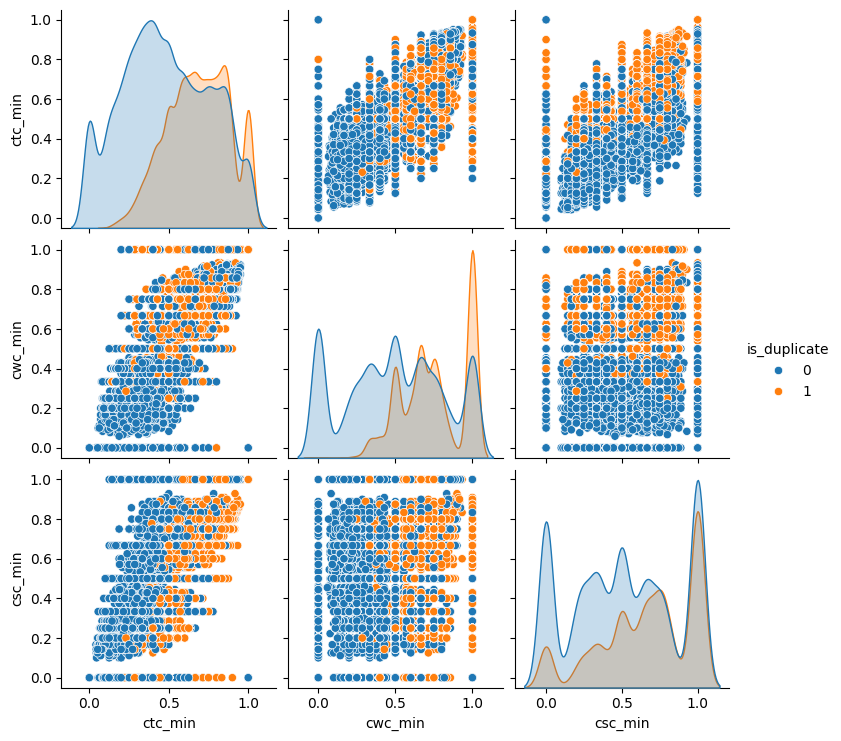

In [28]:
sns.pairplot(new_df[["ctc_min", "cwc_min","csc_min", "is_duplicate"]], hue="is_duplicate")

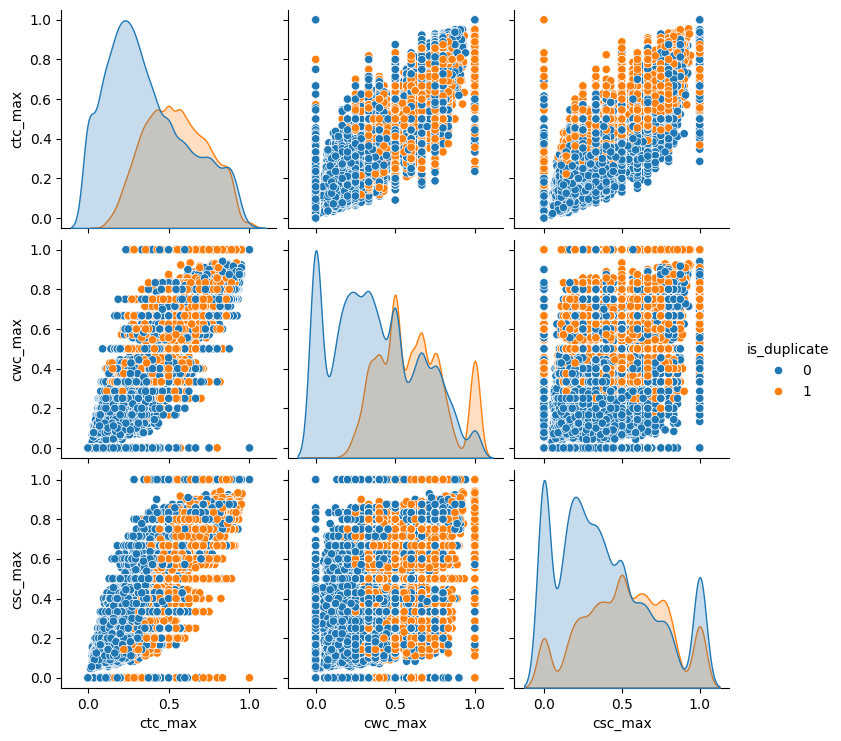

In [29]:
sns.pairplot(new_df[["ctc_max", "cwc_max","csc_max", "is_duplicate"]], hue="is_duplicate")

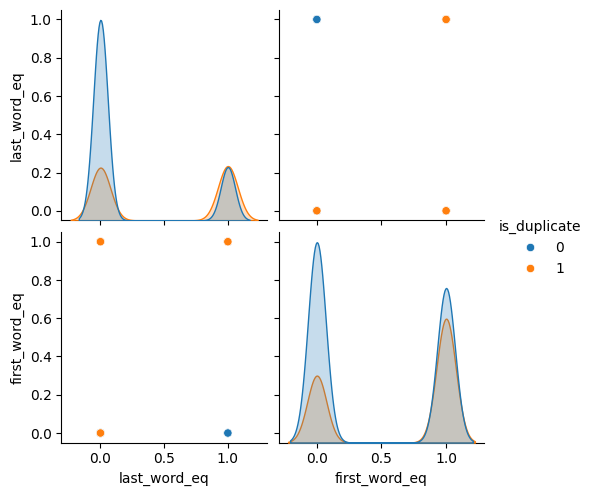

In [30]:
sns.pairplot(new_df[["last_word_eq", "first_word_eq", "is_duplicate"]], hue="is_duplicate")

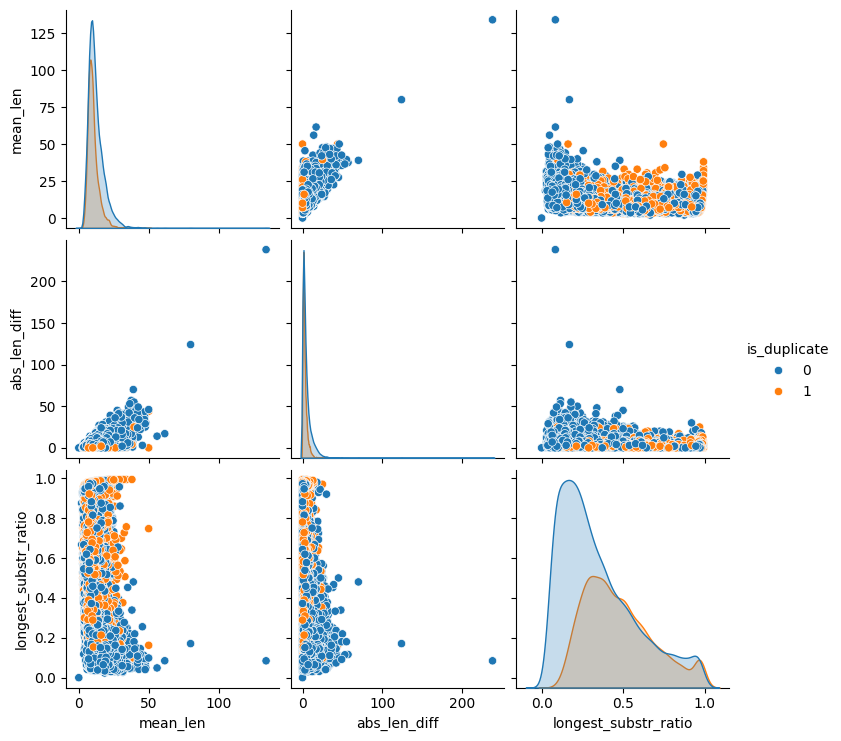

In [31]:
sns.pairplot(new_df[["mean_len", "abs_len_diff", "longest_substr_ratio", "is_duplicate"]], hue="is_duplicate")

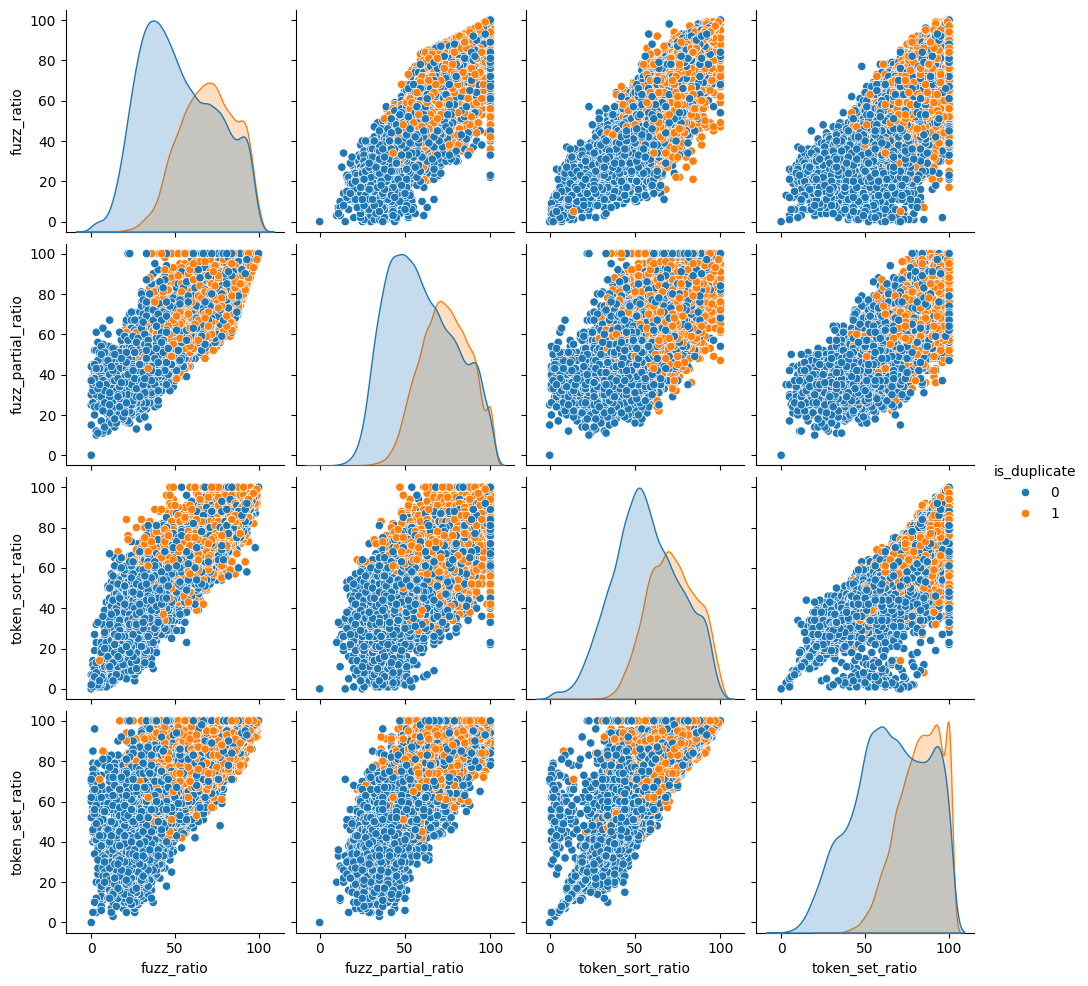

In [32]:
sns.pairplot(new_df[["fuzz_ratio", "fuzz_partial_ratio", "token_sort_ratio", "token_set_ratio", "is_duplicate"]], hue="is_duplicate")

In [33]:
# Using TSNE for Dimentionality reduction for 15 Features
# (Generated after cleaning the data) to 3 dimention

from sklearn.preprocessing import MinMaxScaler

X = MinMaxScaler().fit_transform(new_df[['cwc_min', 'cwc_max', 'csc_min', 'csc_max',
                                          'ctc_min', 'ctc_max', 'last_word_eq',
                                          'first_word_eq', 'abs_len_diff', 'mean_len',
                                          'token_set_ratio', 'token_sort_ratio',
                                          'fuzz_ratio', 'fuzz_partial_ratio', 'longest_substr_ratio']])

y = new_df['is_duplicate'].values

In [ ]:
from sklearn.manifold import TSNE

tsne2d = TSNE(
    n_components=2,
    init='random',  # pca
    random_state=101,
    method='barnes_hut',
    n_iter=1000,
    verbose=2,
    angle=0.5
).fit_transform(X)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.128s...
[t-SNE] Computed neighbors for 30000 samples in 5.994s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sam

In [35]:
tsne3d = TSNE(
    n_components=3,
    init='random',  # pca
    random_state=101,
    method='barnes_hut',
    n_iter=1000,
    verbose=2,
    angle=0.5
).fit_transform(X)

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 30000 samples in 0.081s...
[t-SNE] Computed neighbors for 30000 samples in 4.225s...
[t-SNE] Computed conditional probabilities for sample 1000 / 30000
[t-SNE] Computed conditional probabilities for sample 2000 / 30000
[t-SNE] Computed conditional probabilities for sample 3000 / 30000
[t-SNE] Computed conditional probabilities for sample 4000 / 30000
[t-SNE] Computed conditional probabilities for sample 5000 / 30000
[t-SNE] Computed conditional probabilities for sample 6000 / 30000
[t-SNE] Computed conditional probabilities for sample 7000 / 30000
[t-SNE] Computed conditional probabilities for sample 8000 / 30000
[t-SNE] Computed conditional probabilities for sample 9000 / 30000
[t-SNE] Computed conditional probabilities for sample 10000 / 30000
[t-SNE] Computed conditional probabilities for sample 11000 / 30000
[t-SNE] Computed conditional probabilities for sample 12000 / 30000
[t-SNE] Computed conditional probabilities for sam

In [36]:
import plotly.graph_objs as go
import plotly.io as pio

trace1 = go.Scatter3d(
    x=tsne3d[:,0],
    y=tsne3d[:,1],
    z=tsne3d[:,2],
    mode='markers',
    marker=dict(
        sizemode='diameter',
        color=y,
        colorscale='Portland',
        colorbar=dict(title='duplicate'),
        line=dict(color='rgb(255, 255, 255)'),
        opacity=0.75
    )
)

data = [trace1]
layout = dict(height=800, width=800, title='3d embedding with engineered features')
fig = go.Figure(data=data, layout=layout)

fig.show() 

In [37]:
ques_df = new_df[["question1", "question2"]]
ques_df.head()

,question1,question2
398782,what is the best marketing automation tool for...,what is the best marketing automation tool for...
115086,i am poor but i want to invest what should i do,i am quite poor and i want to be very rich wha...
327711,i am from india and live abroad i met a guy fr...,t i e t to thapar university to thapar univers...
367788,why do so many people in the u s hate the sout...,my boyfriend doesnt feel guilty when he hurts ...
151235,consequences of bhopal gas tragedy,what was the reason behind the bhopal gas tragedy


In [38]:
final_df = new_df.drop(columns=["id","qid1","qid2","question1", "question2"], axis=1)
print(final_df.shape)
final_df.head()

(30000, 23)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,word_total,word_share,cwc_min,cwc_max,...,ctc_max,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio
398782,1,75,76,13,13,12,26,0.46,0.874989,0.874989,...,0.923070,1.0,1.0,0.0,13.0,0.855263,99,99,99,99
115086,0,47,55,12,15,7,22,0.32,0.666644,0.499988,...,0.466664,1.0,1.0,3.0,13.5,0.229167,69,66,65,74
327711,0,102,118,26,20,3,36,0.08,0.000000,0.000000,...,0.115384,0.0,0.0,6.0,23.0,0.048544,26,30,34,43
367788,0,57,143,13,30,0,32,0.00,0.000000,0.000000,...,0.000000,0.0,0.0,17.0,21.5,0.051724,27,46,23,30
151235,0,34,49,5,9,3,13,0.23,0.749981,0.599988,...,0.333330,1.0,0.0,4.0,7.0,0.542857,55,70,48,69


In [39]:
from sklearn.feature_extraction.text import CountVectorizer

question1 = list(ques_df["question1"]) + list(ques_df["question2"])

cv = CountVectorizer(max_features=3000)
question_features = cv.fit_transform(question1)

n = len(ques_df)
q1_arr = question_features[:n]
q2_arr = question_features[n:]

In [40]:
temp_df1 = pd.DataFrame(q1_arr, index=ques_df.index)
temp_df2 = pd.DataFrame(q2_arr, index=ques_df.index)
temp_df = pd.concat([temp_df1, temp_df2], axis=1)
print("Shape of temp dataframe: ", temp_df.shape)
temp_df.head()

Shape of temp dataframe:  (30000, 2)


,0,0
398782,<Compressed Sparse Row sparse matrix of dtype ...,<Compressed Sparse Row sparse matrix of dtype ...
115086,<Compressed Sparse Row sparse matrix of dtype ...,<Compressed Sparse Row sparse matrix of dtype ...
327711,<Compressed Sparse Row sparse matrix of dtype ...,<Compressed Sparse Row sparse matrix of dtype ...
367788,<Compressed Sparse Row sparse matrix of dtype ...,<Compressed Sparse Row sparse matrix of dtype ...
151235,<Compressed Sparse Row sparse matrix of dtype ...,<Compressed Sparse Row sparse matrix of dtype ...


In [41]:
final_df = pd.concat([final_df, temp_df], axis=1)
print("Shape of final dataframe: ", final_df.shape)
final_df.head()

Shape of final dataframe:  (30000, 25)


,is_duplicate,q1_len,q2_len,q1_num_words,q2_num_words,common_words,word_total,word_share,cwc_min,cwc_max,...,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio,0,0
398782,1,75,76,13,13,12,26,0.46,0.874989,0.874989,...,1.0,0.0,13.0,0.855263,99,99,99,99,<Compressed Sparse Row sparse matrix of dtype ...,<Compressed Sparse Row sparse matrix of dtype ...
115086,0,47,55,12,15,7,22,0.32,0.666644,0.499988,...,1.0,3.0,13.5,0.229167,69,66,65,74,<Compressed Sparse Row sparse matrix of dtype ...,<Compressed Sparse Row sparse matrix of dtype ...
327711,0,102,118,26,20,3,36,0.08,0.000000,0.000000,...,0.0,6.0,23.0,0.048544,26,30,34,43,<Compressed Sparse Row sparse matrix of dtype ...,<Compressed Sparse Row sparse matrix of dtype ...
367788,0,57,143,13,30,0,32,0.00,0.000000,0.000000,...,0.0,17.0,21.5,0.051724,27,46,23,30,<Compressed Sparse Row sparse matrix of dtype ...,<Compressed Sparse Row sparse matrix of dtype ...
151235,0,34,49,5,9,3,13,0.23,0.749981,0.599988,...,0.0,4.0,7.0,0.542857,55,70,48,69,<Compressed Sparse Row sparse matrix of dtype ...,<Compressed Sparse Row sparse matrix of dtype ...


In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(final_df.iloc[:,1: ].values, final_df.iloc[:,0].values , test_size=0.2, random_state=42)

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score
from scipy.sparse import csr_matrix, hstack, vstack
rf = RandomForestClassifier(n_estimators=100, random_state=2)
X_train_sparse = hstack([
    csr_matrix(X_train[:, :-2].astype(np.float32)),
    vstack(X_train[:, -2].tolist()),
    vstack(X_train[:, -1].tolist())
]).tocsr()

X_test_sparse = hstack([
    csr_matrix(X_test[:, :-2].astype(np.float32)),
    vstack(X_test[:, -2].tolist()),
    vstack(X_test[:, -1].tolist())
]).tocsr()

rf.fit(X_train_sparse, y_train)
y_pred = rf.predict(X_test_sparse)
accuracy_score(y_test, y_pred)
rf.fit(X_train_sparse, y_train)
y_pred = rf.predict(X_test_sparse)
accuracy_score(y_test, y_pred)

0.7855

In [44]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score
print(classification_report(y_test, y_pred))    

              precision    recall  f1-score   support

           0       0.81      0.86      0.83      3799
           1       0.73      0.66      0.69      2201

    accuracy                           0.79      6000
   macro avg       0.77      0.76      0.76      6000
weighted avg       0.78      0.79      0.78      6000



In [45]:
print(confusion_matrix(y_test, y_pred))

[[3253  546]
 [ 741 1460]]


In [46]:
print(precision_score(y_test, y_pred))

0.7278165503489531


In [47]:
def query_point_creator(q1, q2):
    input_query = []

    # preprocess
    q1 = preprocess(q1)
    q2 = preprocess(q2)

    # fetch basic features
    input_query.append(len(q1))
    input_query.append(len(q2))

    input_query.append(len(q1.split(" ")))
    input_query.append(len(q2.split(" ")))

    def test_common_words(q1, q2):
        w1 = set(q1.split())
        w2 = set(q2.split())
        return len(w1 & w2)

    def test_total_words(q1, q2):
        w1 = set(q1.split())
        w2 = set(q2.split())
        return len(w1) + len(w2)

    def test_fetch_token_features(q1, q2):
        SAFE_DIV = 0.0001
        STOP_WORDS = stopwords.words("english")

        token_features = [0.0] * 8

        q1_tokens = q1.split()
        q2_tokens = q2.split()

        if len(q1_tokens) == 0 or len(q2_tokens) == 0:
            return token_features

        q1_words = set([word for word in q1_tokens if word not in STOP_WORDS])
        q2_words = set([word for word in q2_tokens if word not in STOP_WORDS])

        q1_stops = set([word for word in q1_tokens if word in STOP_WORDS])
        q2_stops = set([word for word in q2_tokens if word in STOP_WORDS])

        common_word_count  = len(q1_words.intersection(q2_words))
        common_stop_count  = len(q1_stops.intersection(q2_stops))
        common_token_count = len(set(q1_tokens).intersection(set(q2_tokens)))

        token_features[0] = common_word_count  / (min(len(q1_words), len(q2_words)) + SAFE_DIV)
        token_features[1] = common_word_count  / (max(len(q1_words), len(q2_words)) + SAFE_DIV)
        token_features[2] = common_stop_count  / (min(len(q1_stops), len(q2_stops)) + SAFE_DIV)
        token_features[3] = common_stop_count  / (max(len(q1_stops), len(q2_stops)) + SAFE_DIV)
        token_features[4] = common_token_count / (min(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
        token_features[5] = common_token_count / (max(len(q1_tokens), len(q2_tokens)) + SAFE_DIV)
        token_features[6] = int(q1_tokens[-1] == q2_tokens[-1])
        token_features[7] = int(q1_tokens[0]  == q2_tokens[0])

        return token_features

    def test_fetch_length_features(q1, q2):
        length_features = [0.0] * 3

        q1_tokens = q1.split()
        q2_tokens = q2.split()

        if len(q1_tokens) == 0 or len(q2_tokens) == 0:
            return length_features

        length_features[0] = abs(len(q1_tokens) - len(q2_tokens))
        length_features[1] = (len(q1_tokens) + len(q2_tokens)) / 2

        strs = list(distance.lcsubstrings(q1, q2))
        length_features[2] = len(strs[0]) / (min(len(q1), len(q2)) + 1)

        return length_features

    def test_fetch_fuzzy_features(q1, q2):
        fuzzy_features = [0.0] * 4
        fuzzy_features[0] = fuzz.QRatio(q1, q2)
        fuzzy_features[1] = fuzz.partial_ratio(q1, q2)
        fuzzy_features[2] = fuzz.token_sort_ratio(q1, q2)
        fuzzy_features[3] = fuzz.token_set_ratio(q1, q2)
        return fuzzy_features

    # ✅ teen basic features (missing wali line fix)
    input_query.append(test_common_words(q1, q2))   # 5 ← ye missing thi
    input_query.append(test_total_words(q1, q2))    # 6
    input_query.append(round(test_common_words(q1, q2) / test_total_words(q1, q2), 2))  # 7

    # fetch token features  → 8 values (8-15)
    token_features = test_fetch_token_features(q1, q2)
    input_query.extend(token_features)

    # fetch length based features → 3 values (16-18)
    length_features = test_fetch_length_features(q1, q2)
    input_query.extend(length_features)

    # fetch fuzzy features → 4 values (19-22)
    fuzzy_features = test_fetch_fuzzy_features(q1, q2)
    input_query.extend(fuzzy_features)

    # bow feature for q1
    q1_bow = cv.transform([q1]).toarray()

    # bow feature for q2
    q2_bow = cv.transform([q2]).toarray()

    return np.hstack((np.array(input_query).reshape(1, 22), q1_bow, q2_bow))

In [48]:
# test
query_point_creator("How are you?", "How do you do?")


array([[11., 13.,  3., ...,  0.,  0.,  0.]], shape=(1, 6022))

In [50]:
rf.predict(query_point_creator("How are you?", "How do you do?"))

array([0])

In [49]:
import pickle
pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(cv, open("cv.pkl", "wb"))